C:\Users\23109\AppData\Local\Temp\ipykernel_22780\3099703490.py:74: RuntimeWarning: overflow encountered in exp
  result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))


[(45.50205118691438+0j)]


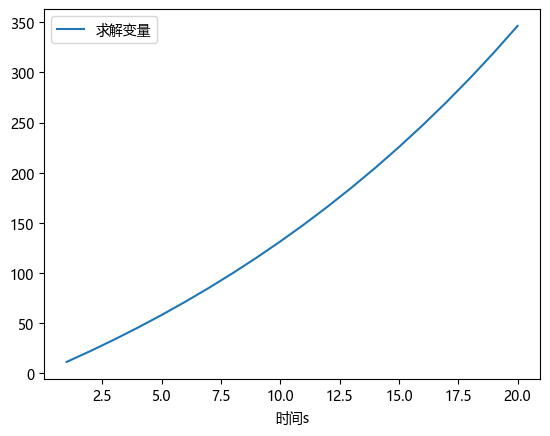

In [15]:
from numpy import *
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']

from math import ceil

complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    travel_time_between_two_legs = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * travel_time_between_two_legs
    n1 = 1
    n2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / (N * (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2))
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(complex_unit * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/2))/2)/transition_frequency_of_atom
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(complex_unit * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(complex_unit * (driving_frequency - 2 * k2 * pi / N / T) * t)
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+complex_unit*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+complex_unit*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-complex_unit*k0*(x+x0-T+t)))

time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result



def equation(Y, t,d):
    
    x,y = Y(t)
    xd,yd = Y(t-d)
    #xm , ym = Y(t-m)

    def shibu(t):
        a=(-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))
        result = re(a)
        return result
    def xubu(t):
        a=(-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))
        result = re(a)
        return result
    return [shibu(t),xubu(t)]

def initial_history_func(t):
    return [1, 1]

plt.rcParams['font.size'] = 8
fig, axs = plt.subplots(1, 1)
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
fig.suptitle("$x'(t)=x(t) y(t-d); y'(t)=y(t) x(t-d)$ solved by ddeint")

ts = np.linspace(0, 3, 20)
mmm = (1,)
ys = ddeint(equation, initial_history_func, ts, fargs= mmm)
axs.plot(ts, ys[:,0], color='red', linewidth=1)
axs.plot(ts, ys[:,1], color='blue', linewidth=1)
axs.set_title('$ihf_x(t)=1; ihf_y(t)=-1; d=0.5$')

plt.show()










   

def bt(tt):
    if tt>=0:
        return solve_ode(tt)
    else:
        return 0

bt(2)
def kmax(k):
    result = (sin(k*pi/N))**2*(transition_frequency_of_atom/N/gamma+(1/tan(k*pi/N+10**(-20)))/2)/(k*pi/N+10**(-20))
    return result

km = np.zeros(20*N)
for i in range(20*N):
    km[i] = kmax(i)

b = np.zeros(20*N)
for i in range(20*N):
    b[i] = i
#plt.scatter(b,km)



In [ ]:
 def fun(t,y):
        #def second_term(t):
        #sum = 0
        #for i in range(N):
        #    sum += exp(-complex_unit*driving_frequency*i*T)*y(t-i*T)
        dydt = [-1*complex_unit*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2*y]
        return dydt
    
    tmax_ceil=math.ceil(tmax/T)
    y0 = [1+0j]
    yy = solve_ivp(fun,(0,tmax_ceil),y0,t_eval = np.arange(1,tmax_ceil,1) )
    t = yy.t
    data = yy.y
    print([data[0,3]])
    adata = zeros([1,tmax_ceil-1])
    for i in range(tmax_ceil-1):
        adata[0,i] = np.real(data[0,i])
    plt.plot(t, adata[0,:])
    plt.xlabel("时间s")
    plt.legend(["求解变量"])
    plt.show()

In [18]:
import numpy as np

import brainpy as bp
import brainpy.math as bm

bm.set_platform('cpu')

In [7]:
pip install taichi==1.7.0 --user

  Obtaining dependency information for taichi==1.7.0 from https://files.pythonhosted.org/packages/cd/97/3fe7258d9f9274e031cdd15605bd90f514bd28089daae11348c832ef29ce/taichi-1.7.0-cp311-cp311-win_amd64.whl.metadata
  Using cached taichi-1.7.0-cp311-cp311-win_amd64.whl.metadata (12 kB)
Using cached taichi-1.7.0-cp311-cp311-win_amd64.whl (83.0 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import matplotlib.pyplot as plt

import brainpy as bp
import brainpy.math as bm

bm.enable_x64()

#bp.__version__

In [35]:
import brainpy as bp
help(bp)

Help on package brainpy:

NAME
    brainpy - # -*- coding: utf-8 -*-

PACKAGE CONTENTS
    _add_deprecations
    _src (package)
    algorithms (package)
    analysis
    channels
    check
    checkpoints
    connect
    dnn (package)
    dyn (package)
    encoding
    errors
    experimental
    initialize
    inputs
    integrators (package)
    layers
    losses
    math (package)
    measure
    mixin
    neurons
    optim
    rates
    running
    synapses
    synouts
    synplast
    tools
    types

SUBMODULES
    conn
    fde
    init
    modes
    ode
    sde
    train

DATA
    share = <brainpy._src.context._ShareContext object>

VERSION
    2.4.6.post5

FILE
    c:\users\23109\anaconda3\lib\site-packages\brainpy\__init__.py




  0%|          | 0/200 [00:00<?, ?it/s]

200


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

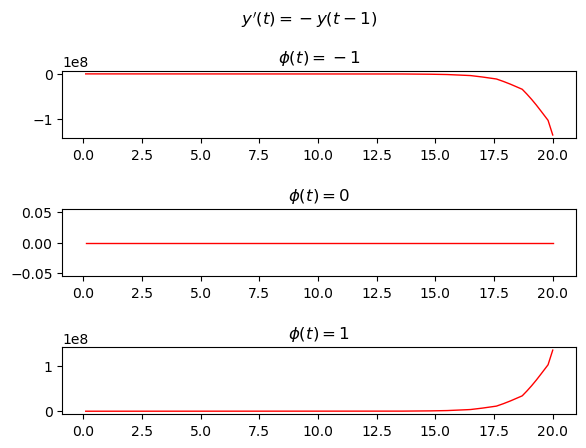

In [5]:
def delay_odeint(duration, eq, args=None, inits=None,state_delays=None, neutral_delays=None,monitors=('x',), method='euler', dt=0.1):
  # define integrators of ODEs based on `brainpy.odeint`
  dde = bp.odeint(eq,state_delays=state_delays,neutral_delays=neutral_delays,method=method)
  # define IntegratorRunner
  runner = bp.IntegratorRunner(dde,monitors=monitors,dt=dt,inits=inits)
  runner.run(duration, args=args)
  return runner.mon

def equation(x, t, xdelay):
  for i in range(8):
    sum = xdelay(t-0.0001)
    sum += xdelay(t-i/10)
  return sum


case1_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=-1.,dt = 0.1, interp_method='round')
case2_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=0., dt = 0.1,interp_method='round')
case3_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=1.,dt = 0.1, interp_method='round')
case1 = delay_odeint(20., equation, args={'xdelay': case1_delay}, state_delays={'x': case1_delay})  # delay for variable "x"
print(len(case1.ts))
case2 = delay_odeint(20., equation, args={'xdelay': case2_delay}, state_delays={'x': case2_delay})
case3 = delay_odeint(20., equation, args={'xdelay': case3_delay}, state_delays={'x': case3_delay})
fig, axs = plt.subplots(3, 1)
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
fig.suptitle("$y'(t)=-y(t-1)$")

axs[0].plot(case1.ts, case1.x, color='red', linewidth=1)
axs[0].set_title('$\phi(t)=-1$')

axs[1].plot(case2.ts, case2.x, color='red', linewidth=1)
axs[1].set_title('$\phi(t)=0$')

axs[2].plot(case3.ts, case3.x, color='red', linewidth=1)
axs[2].set_title('$\phi(t)=1$')

plt.show()

In [1]:
def eq(x, t):
  return -delay(t-1) + 0.3 * delay(t - 2) 


delay = bm.TimeDelay(bm.ones(1), 2., before_t0=1., dt=0.01, interp_method='round')
mon = delay_odeint(10., eq, inits=[100.], state_delays={'x': delay}, dt=0.01)
fig, axs = plt.subplots(1, 1)
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
fig.suptitle("$y'(t)=-y(t-1) + 0.3\ y(t-2)$")

axs.plot(mon.ts, mon.x, color='red', linewidth=1)
axs.set_title('$\phi(t)=1$')

plt.show()

NameError: name 'bm' is not defined

In [4]:
import matplotlib.pyplot as plt

import brainpy as bp
import brainpy.math as bm

def delay_odeint(duration, eq, args=None, inits=None,state_delays=None, neutral_delays=None,monitors=('x',), method='euler', dt=0.1):
  # define integrators of ODEs based on `brainpy.odeint`
  dde = bp.odeint(eq,state_delays=state_delays,neutral_delays=neutral_delays,method=method)
  # define IntegratorRunner
  runner = bp.IntegratorRunner(dde,monitors=monitors,dt=dt,inits=inits)
  runner.run(duration, args=args)
  return runner.mon

def equation(x, t, xdelay):
  return -xdelay(t - 1)


case1_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=-1000, interp_method='round')
case2_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=0., interp_method='round')
case3_delay = bm.TimeDelay(bm.zeros((1,)), 1., before_t0=1., interp_method='round')
case1 = delay_odeint(200., equation, args={'xdelay': case1_delay}, state_delays={'x': case1_delay})  # delay for variable "x"
print(case1.ts)
case2 = delay_odeint(20., equation, args={'xdelay': case2_delay}, state_delays={'x': case2_delay})
case3 = delay_odeint(20., equation, args={'xdelay': case3_delay}, state_delays={'x': case3_delay})
fig, axs = plt.subplots(3, 1)
fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
fig.suptitle("$y'(t)=-y(t-1)$")

axs[0].plot(case1.ts, case1.x, color='red', linewidth=1)
axs[0].set_title('$\phi(t)=-1$')

axs[1].plot(case2.ts, case2.x, color='red', linewidth=1)
axs[1].set_title('$\phi(t)=0$')

axs[2].plot(case3.ts, case3.x, color='red', linewidth=1)
axs[2].set_title('$\phi(t)=1$')

plt.show()

ValueError: "before_t0" does not support <class 'complex'>

In [15]:

def dde_solve(dde, statevar, delayedvars, history, tmax, timestep):
    # Check validity of delays.
    if min(delayedvars.values()) < 0:
        raise ValueError("This function will not work with negative delays. "
            "Consider consulting a fortune teller instead.")
    if any(val<timestep for val in delayedvars.values()):
        raise ValueError("Time step should not be larger than delay.")

    # Set up variables and delays.
    delayedvars = delayedvars.items()
    dde = dde.subs({v: statevar for v, delay in delayedvars if delay == 0})
    delayedvars = [(v, delay) for v, delay in delayedvars if delay != 0]
    allvars = [str(statevar)] + [str(v) for v, delay in delayedvars]
    delays = [delay for v, delay in delayedvars]

    # Set up fast functions.
    dde_func = fast_float(dde, *allvars)
    history_func = fast_float(history, "t")

    # Adjust the timestep if necessary
    mindelay = min(delays) if delays else timestep
    timestepcorrectionfactor = ceil(timestep / mindelay)
    timestep /= timestepcorrectionfactor

    # A function to perform history lookups.
    def lookup(t):
        """Does a history lookup at each delay from t, stores result in allvars[1:]"""
        for i, delay in enumerate(delays):
            if t - delay <= 0:
                allvars[i+1] = history_func(t - delay)
            else:
                r = (t - delay) / timestep
                n = floor(r)
                r -= n
                allvars[i+1] = result[n]*(1 - r) + result[n + 1]*r

    # Set up for the first iteration.
    result = [history_func(0)]
    lookup(0)
    for t in sxrange(0, tmax - timestep, timestep):
        # Compute k1. Note history lookup has already been done.
        allvars[0] = result[-1]
        k1 = dde_func(*allvars)
        # Compute k2.
        lookup(t + timestep/2)
        allvars[0] += timestep/2 * k1
        k2 = dde_func(*allvars)
        # Compute k3. Note history lookup has already been done.
        allvars[0] = result[-1] + timestep/2 * k2
        k3 = dde_func(*allvars)
        # Compute k4.
        lookup(t + timestep)
        allvars[0] = result[-1] + timestep * k3
        k4 = dde_func(*allvars)
        # Finally, compute the RK4 weighted average.
        result.append(result[-1] + (k1 + 2*k2 + 2*k3 + k4)/6 * timestep)
    return result[::timestepcorrectionfactor]
#var('old_x') # old x represents the delayed state variable

history = .2 # we'll assume that x = .2 for t <= 0
tmax = 100 # time to simulate to
dt = .1 # timestep
delay_amt = 5 # amount of time delay
#t = range(0, tmax, dt)
equation = 3.5*(x^2/(1+x^2))-old_x
sol = dde_solve(equation, x, {old_x: 5}, history, tmax, dt)
list_plot(sol)

NameError: name 'x' is not defined

实部  1.97169e-06
虚部  0
实部  1.97169e-06
虚部  -2.40012e-15
实部  1.97169e-06
虚部  -4.8991e-14
实部  1.97169e-06
虚部  -2.44955e-14
实部  1.97172e-06
虚部  -2.44983e-10
实部  1.97196e-06
虚部  -2.69489e-09
实部  1.97196e-06
虚部  -2.69489e-09
实部  1.97219e-06
虚部  -5.14539e-09
实部  1.97418e-06
虚部  -2.7361e-08
实部  1.97418e-06
虚部  -2.7361e-08
实部  1.98041e-06
虚部  -1.39681e-07
实部  1.98041e-06
虚部  -1.39681e-07
实部  1.97704e-06
虚部  -6.59122e-08
实部  1.97704e-06
虚部  -6.59122e-08
实部  1.97915e-06
虚部  -1.04585e-07
实部  1.98113e-06
虚部  -1.8641e-07
实部  1.98113e-06
虚部  -1.8641e-07
实部  1.97974e-06
虚部  -2.68576e-07
实部  1.97974e-06
虚部  -2.68576e-07
实部  1.96533e-06
虚部  -4.45228e-07
实部  1.96533e-06
虚部  -4.45228e-07
实部  1.97233e-06
虚部  -3.81637e-07
实部  1.97233e-06
虚部  -3.81637e-07
实部  1.95848e-06
虚部  -4.94722e-07
实部  1.92194e-06
虚部  -6.78673e-07
实部  1.86816e-06
虚部  -8.60109e-07
实部  1.86816e-06
虚部  -8.60109e-07
实部  1.79729e-06
虚部  -1.03742e-06
实部  1.79729e-06
虚部  -1.03742e-06
实部  1.70964e-06
虚部  -1.20899e-06
实部  1.70964e-06
虚部  -1.208

c:\Users\23109\anaconda3\Lib\site-packages\scipy\integrate\_ode.py:1011: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


实部  0.00266207
虚部  0.015275
实部  0.00266208
虚部  0.015275
实部  0.00266432
虚部  0.0152748
实部  0.0026632
虚部  0.0152749
实部  0.0026632
虚部  0.0152749
实部  0.00266432
虚部  0.0152748
实部  0.00266432
虚部  0.0152748
实部  0.00267411
虚部  0.015274
实部  0.00267411
虚部  0.015274
实部  0.00266735
虚部  0.0152746
实部  0.00266735
虚部  0.0152746
实部  0.00267037
虚部  0.0152743
实部  0.00268257
虚部  0.0152731
实部  0.00268257
虚部  0.0152731
实部  0.00276712
虚部  0.0152622
实部  0.00276712
虚部  0.0152622
实部  0.00270807
虚部  0.0152704
实部  0.00270807
虚部  0.0152704
实部  0.00273355
虚部  0.0152672
实部  0.00280031
虚部  0.0152564
实部  0.00280031
虚部  0.0152564
实部  0.00286666
虚部  0.0152425
实部  0.00286666
虚部  0.0152425
实部  0.00301056
虚部  0.0152007
实部  0.00301056
虚部  0.0152007
实部  0.00295212
虚部  0.0152197
实部  0.00295212
虚部  0.0152197
实部  0.00303627
虚部  0.0151914
实部  0.00319099
虚部  0.0151235
实部  0.0033376
虚部  0.0150374
实部  0.0033376
虚部  0.0150374
实部  0.00347395
虚部  0.014934
实部  0.00347395
虚部  0.014934
实部  0.00342792
虚部  0.0149718
实部  0.00342792
虚部  0.014

ValueError: object arrays are not supported

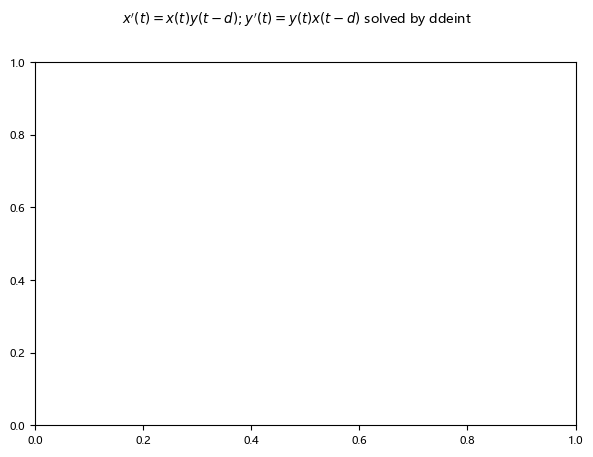

In [6]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    T = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * T
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


def solve(canshu):
    def equation(Y, t,d):
        
        x,y = Y(t)
        xd,yd = Y(t-d)
        #xm , ym = Y(t-m)

        def shibu(t):
            a = (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))
            result = re(a)
            #print(a)
            return result
        def xubu(t):
            a = (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))
            result = im(a)
            return result
        print("实部 ",'%g'%shibu(t))
        print("虚部 ",'%g'%xubu(t))
        return [shibu(t),xubu(t)]

    def initial_history_func(t):
        return [0, 0]

    plt.rcParams['font.size'] = 8
    fig, axs = plt.subplots(1, 1)
    fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    fig.suptitle("$x'(t)=x(t) y(t-d); y'(t)=y(t) x(t-d)$ solved by ddeint")
    

    ts = np.linspace(0,2500, 20)
    mmm = (T,)
    
    ys = ddeint(equation, initial_history_func, ts, fargs= mmm)
    #print('%g'%tmax)
    axs.plot(ts, ys[:,0], color='red', linewidth=1)
    axs.plot(ts, ys[:,1], color='blue', linewidth=1)
    axs.set_title('$ihf_x(t)=1; ihf_y(t)=-1; d=0.5$')

    plt.show()
    #return 0

solve(0)



实部  1.97169e-06
虚部  0
实部  1.97169e-06
虚部  -1.04619e-15
实部  1.97169e-06
虚部  -3.23448e-14
实部  1.97169e-06
虚部  -1.61724e-14
实部  1.97171e-06
虚部  -1.61742e-10
实部  1.97187e-06
虚部  -1.77914e-09
实部  1.97187e-06
虚部  -1.77914e-09
实部  1.97202e-06
虚部  -3.39679e-09
实部  1.97351e-06
虚部  -1.95873e-08
实部  1.98021e-06
虚部  -1.32814e-07
实部  1.98021e-06
虚部  -1.32814e-07
实部  1.97654e-06
虚部  -5.84116e-08
实部  1.97654e-06
虚部  -5.84116e-08
实部  1.97881e-06
虚部  -9.73625e-08
实部  1.98109e-06
虚部  -1.79144e-07
实部  1.98109e-06
虚部  -1.79144e-07
实部  1.98e-06
虚部  -2.6128e-07
实部  1.98e-06
虚部  -2.6128e-07
实部  1.96628e-06
虚部  -4.37576e-07
实部  1.96628e-06
虚部  -4.37576e-07
实部  1.973e-06
虚部  -3.74267e-07
实部  1.973e-06
虚部  -3.74267e-07
实部  1.95958e-06
虚部  -4.87302e-07
实部  1.92379e-06
虚部  -6.71126e-07
实部  1.87078e-06
虚部  -8.52507e-07
实部  1.87078e-06
虚部  -8.52507e-07
实部  1.80072e-06
虚部  -1.02984e-06
实部  1.80072e-06
虚部  -1.02984e-06
实部  1.71389e-06
虚部  -1.20152e-06
实部  1.71389e-06
虚部  -1.20152e-06
实部  1.61074e-06
虚部  -1.36596e-06


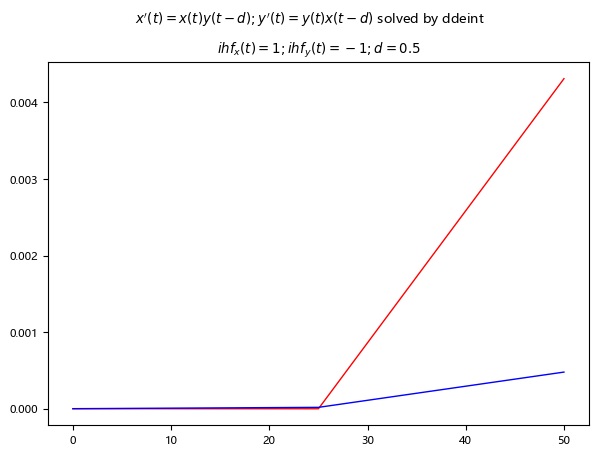

In [1]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    T = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * T
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


def solve(canshu):
    def equation(Y, t,d):
        
        x,y = Y(t)
        xd,yd = Y(t-d)
        #xm , ym = Y(t-m)
        def oone(t):
            return (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)
        def ttwo(t):
            return gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))
        def tthree(t):
            return I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))

        def shibu(t):
            
            a = oone(t)+ttwo(t)+tthree(t)
            result = re(a)
            #print(a)
            return result
        def xubu(t):
           
           
            a = oone(t)+ttwo(t)+tthree(t)
            result = im(a)
            return result
        print("实部 ",'%g'%shibu(t))
        print("虚部 ",'%g'%xubu(t))
        return [shibu(t),xubu(t)]

    def initial_history_func(t):
        return [0, 0]

    plt.rcParams['font.size'] = 8
    fig, axs = plt.subplots(1, 1)
    fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    fig.suptitle("$x'(t)=x(t) y(t-d); y'(t)=y(t) x(t-d)$ solved by ddeint")
    

    ts = np.linspace(0,50, 3)
    mmm = (T,)
    
    ys = ddeint(equation, initial_history_func, ts, fargs= mmm)
    #print('%g'%tmax)
    axs.plot(ts, ys[:,0], color='red', linewidth=1)
    axs.plot(ts, ys[:,1], color='blue', linewidth=1)
    axs.set_title('$ihf_x(t)=1; ihf_y(t)=-1; d=0.5$')

    plt.show()
    #return 0

solve(1)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

ValueError: object arrays are not supported

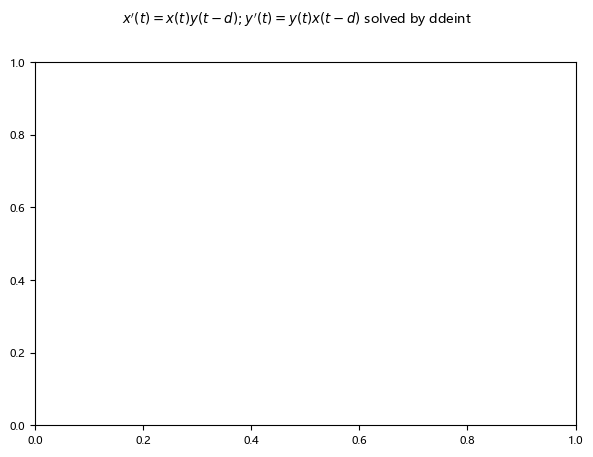

In [23]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    T = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * T
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


def solve(canshu):
    def equation(Y, t,d):
        
        x,y = Y(t)
        xd,yd = Y(t-d)
        #xm , ym = Y(t-m)
        def righthand(t):

            def oone(t):
                return (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)
            #def ttwo(t):
                #return gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))
            #def tthree(t):
                #return I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))
            #a = oone(t)+ttwo(t)+tthree(t)
            a = x*yd+y*xd*I
            b = re(a)
            c = im(a)
        
            return b, c
        r1,r2 = righthand(t)

        
        print("实部 ",'%g'%r1)
        #print("虚部 ",'%g'%r2)
        return [r1,r2]

    def initial_history_func(t):
        return [2, 1]

    plt.rcParams['font.size'] = 8
    fig, axs = plt.subplots(1, 1)
    fig.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    fig.suptitle("$x'(t)=x(t) y(t-d); y'(t)=y(t) x(t-d)$ solved by ddeint")
    

    ts = np.arange(0,300)
    print(ts)
    mmm = (T,)
    
    ys = ddeint(equation, initial_history_func, ts, fargs= mmm)
    #print('%g'%tmax)
    axs.plot(ts, ys[:,0], color='red', linewidth=1)
    print(ys[:,0])
    axs.plot(ts, ys[:,1], color='blue', linewidth=1)
    axs.set_title('$ihf_x(t)=1; ihf_y(t)=-1; d=0.5$')

    plt.show()
    #return 0

solve(3)

In [26]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    T = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * T
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


x = symbols('x',real=True)
y = symbols('y',real=True)
xd = symbols('xd',real=True)
yd = symbols('yd',real=True)
t = symbols('t',real=True)
fangcheng = (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))        
b = re(fangcheng)
c = im(fangcheng)   

print(b)
print(c)
    #x,y = Y(t)
    #xd,yd = Y(t-d)
        #xm , ym = Y(t-m)
        

0.15*x + 0.05*xd*cos(4.1e-14*pi) + y*(0.999999999999999 + 9/(exp(1000*t - 82000*pi) + 1) + 9/(exp(-1000*t + 635000*pi) + 1)) - 0.05*yd*sin(4.1e-14*pi) - 0.158113883008419*sqrt(2)*(-2.08073484738687e-5*exp(-0.0025*t**2/pi**2 + 0.3075*t/pi)*cos(t)/pi**0.75 + 1.04166122894261e-12*exp(-0.0025*t**2/pi**2 + 0.5125*t/pi)*cos(t)/pi**0.75)
-x*(0.999999999999999 + 9/(exp(1000*t - 82000*pi) + 1) + 9/(exp(-1000*t + 635000*pi) + 1)) + 0.05*xd*sin(4.1e-14*pi) + 0.15*y + 0.05*yd*cos(4.1e-14*pi) + 0.158113883008419*sqrt(2)*(-2.08073484738687e-5*exp(-0.0025*t**2/pi**2 + 0.3075*t/pi)*sin(t)/pi**0.75 + 1.04166122894261e-12*exp(-0.0025*t**2/pi**2 + 0.5125*t/pi)*sin(t)/pi**0.75)


In [4]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 1
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 10**(-10)
driving_strength = 0/1

if dark == 0:
    T = (15+1/10) * Ta * (1+10**(-15))
    gamma = 0.1 * transition_frequency_of_atom / N**2
    total_evolution_time = 20 * T
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 20
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

dx = nk/4*2*pi
x0 = -3*T/2
k0 = transition_frequency_of_atom
sigma_k = 1/2/dx
wave_packet_num = 2

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    #result = 2
    result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


x = symbols('x',real=True)
y = symbols('y',real=True)
xd = symbols('xd',real=True)
yd = symbols('yd',real=True)
t = symbols('t',real=True)
fangcheng = (-I*(transition_frequency_of_atom*tweezer(t)-driving_frequency)+N*gamma/2)*(x+I*y)+gamma*((x+I*y)*2*exp(I*driving_frequency*0*T)+(xd+I*yd)*1*exp(I*driving_frequency*1*T))+I*sqrt(gamma/2)*(phi_0(0,t)+phi_0(T,t))        
b = re(fangcheng)
c = im(fangcheng)   

print(b)
print(c)
    #x,y = Y(t)
    #xd,yd = Y(t-d)
        #xm , ym = Y(t-m)
        

0.15*x + 0.05*xd*cos(4.1e-14*pi) + y*(0.999999999999999 + 9/(exp(1000*t - 82000*pi) + 1) + 9/(exp(-1000*t + 635000*pi) + 1)) - 0.05*yd*sin(4.1e-14*pi) - 0.158113883008419*sqrt(2)*(-2.08073484738687e-5*exp(-0.0025*t**2/pi**2 + 0.3075*t/pi)*cos(t)/pi**0.75 + 1.04166122894261e-12*exp(-0.0025*t**2/pi**2 + 0.5125*t/pi)*cos(t)/pi**0.75)
-x*(0.999999999999999 + 9/(exp(1000*t - 82000*pi) + 1) + 9/(exp(-1000*t + 635000*pi) + 1)) + 0.05*xd*sin(4.1e-14*pi) + 0.15*y + 0.05*yd*cos(4.1e-14*pi) + 0.158113883008419*sqrt(2)*(-2.08073484738687e-5*exp(-0.0025*t**2/pi**2 + 0.3075*t/pi)*sin(t)/pi**0.75 + 1.04166122894261e-12*exp(-0.0025*t**2/pi**2 + 0.5125*t/pi)*sin(t)/pi**0.75)


In [1]:
pip show numpy

Name: numpy
Version: 1.23.2
Summary: NumPy is the fundamental package for array computing with Python.
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: BSD
Location: c:\Users\23109\anaconda3\Lib\site-packages
Requires: 
Required-by: astropy, bokeh, Bottleneck, brainpy, CHSPy, contourpy, daal4py, datashader, datashape, ddeint, gensim, h5py, holoviews, hvplot, imagecodecs, imageio, imbalanced-learn, jax, jaxlib, jitcdde, jitcode, jitcxde-common, matplotlib, mkl-fft, mkl-random, ml-dtypes, numba, numexpr, opt-einsum, pandas, patsy, pyarrow, pyerfa, PyWavelets, qutip, scikit-image, scikit-learn, scipy, seaborn, statsmodels, tables, taichi, taichi-nightly, tifffile, transformers, xarray
Note: you may need to restart the kernel to use updated packages.


In [2]:
from numpy import *
#from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.integrate import solve_ivp
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
from ddeint import ddeint
#from math import ceil
from sympy import *




#complex_unit = 1j
dark = 0
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 1
driving_strength = 0/1

if dark == 0:
    T = (10+5/10) * Ta * (1+10**(-15))
    #T = (10+5/10) * Ta * (1+10**(-15)) * 0.1
    #T = 15.708
    gamma = 0.5 * transition_frequency_of_atom / N**2
    #gamma = 0.05
    total_evolution_time = 20 * T / 2
    k1 = 1
    k2 = 1
    
if dark == 1:
    asy = 1
    nk = 2
    K = nk * N + 1
    dw = 0.05
    if N == 2:
        gamma = dw
    else:
        gamma = dw / abs(N * (1 / tan (K*pi/N)) / 2)
    T = asy * 2 * pi * K / N / (transition_frequency_of_atom + N * gamma * (1/ tan (K * pi / N) ) / 2)
    stable_amplitude_dark_state = b0 / (1 + N * gamma * T / (2 * (sin(K * pi / N)) ** 2))
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t)
        return result
    k1 = K 
    k2 = K
    tmax = 20 * (nk + 1) * (N * T / K)

if dark == 2:
    asy = 1
    nk = 1
    k1 = nk * N - 1
    k2 = nk * N + 1
    def gamma_t(a,b):
        result = 4 * pi * (a - b) / N**2 / ((1/tan(a*pi/N))-(1/tan(b*pi/N)))
        return result
    T = asy*(2*pi*k1/N-N*gamma_t(k1,k2)*(1/tan(k1*pi/N))/2)/transition_frequency_of_atom
    gamma = gamma_t(k1,k2)/T
    def beta_t(t,k1,k2):
        result = b0 / (1 + N * gamma * T / 2 / (sin(k1 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k1 * pi / N / T) * t) + b0 / (1 + N * gamma * T / 2 / (sin(k2 * pi / N)**2)) * exp(I * (driving_frequency - 2 * k2 * pi / N / T) * t)
        return result
    tmax = 20/abs(k1/N/T-k2/N/T)

    #dx = nk/4*2*pi
    #x0 = -3*T/2
    #k0 = transition_frequency_of_atom
    #sigma_k = 1/2/dx
wave_packet_num = 0

if wave_packet_num == 1:
    def phi_0(x,t):
        result = sqrt(1-b0**2)*((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))
        return result 
if wave_packet_num == 2:
    def phi_0(x,t):
        result = sqrt(1-b0**2)/sqrt(2)*(((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x-x0-t)**2+I*k0*(x-x0-t))+((2*sigma_k**2/pi)**(1/4))*exp(-sigma_k**2*(x+x0-(N-1)*T+t)**2-I*k0*(x+x0-T+t)))
        return result
time_releasing = 5*T
def tweezer(t):
    result = 1
    #result = 9/(1+exp((t-T/2+x0)*1000))+1+9/(1+exp((tmax-time_releasing-t)*1000))
    return result


x = symbols('x',real=True)
y = symbols('y',real=True)
xd = symbols('xd',real=True)
yd = symbols('yd',real=True)
t = symbols('t',real=True)
fangcheng = (-I*(transition_frequency_of_atom-driving_frequency)+N*gamma/2)*(x+I*y)-gamma*((x+I*y)*2+(xd+I*yd)*1)  
b = re(fangcheng)
c = im(fangcheng)   


print(fangcheng)
print(b)
print(type(b))
print(c)
    #x,y = Y(t)
    #xd,yd = Y(t-d)
        #xm , ym = Y(t-m)
print(T)      
print(type(print(type(b))))

-0.25*x - 0.125*xd - 0.25*I*y - 0.125*I*yd + (0.125 - 0.999999999999999*I)*(x + I*y)
-0.125*x - 0.125*xd + 0.999999999999999*y
<class 'sympy.core.add.Add'>
-0.999999999999999*x - 0.125*y - 0.125*yd
21.0*pi
<class 'sympy.core.add.Add'>
<class 'NoneType'>


In [4]:
dark = 0
N = 2
transition_frequency_of_atom = 1
Ta = 2*pi/transition_frequency_of_atom
driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
b0 = 1
driving_strength = 0/1

if dark == 0:
    T = (10+5/10) * Ta * (1+10**(-15))
    #T = (10+5/10) * Ta * (1+10**(-15)) * 0.1
    #T = 15.708
    gamma = 0.5 * transition_frequency_of_atom / N**2
    #gamma = 0.05
    total_evolution_time = 20 * T / 2
    k1 = 1
    k2 = 1

x = symbols('x',real=True)
y = symbols('y',real=True)
xd = symbols('xd',real=True)
yd = symbols('yd',real=True)
t = symbols('t',real=True)
fangcheng = (-I*(transition_frequency_of_atom-driving_frequency)+N*gamma/2)*(x+I*y)-gamma*((x+I*y)*2+(xd+I*yd)*1)  
b = re(fangcheng)
c = im(fangcheng)
print(b)
print(c)
print(T)

-0.125*x - 0.125*xd + 0.999999999999999*y
-0.999999999999999*x - 0.125*y - 0.125*yd
21.0*pi


In [6]:
# dark = 0
# N = 2
# transition_frequency_of_atom = 1
# Ta = 2*pi/transition_frequency_of_atom
# driving_frequency = 0*transition_frequency_of_atom + 10**(-15)
# b0 = 1
# driving_strength = 0/1

# if dark == 0:
#     T = (10+5/10) * Ta * (1+10**(-15))
#     #T = (10+5/10) * Ta * (1+10**(-15)) * 0.1
#     #T = 15.708
#     gamma = 0.5 * transition_frequency_of_atom / N**2
#     #gamma = 0.05
#     total_evolution_time = 20 * T / 2
#     k1 = 1
#     k2 = 1

x = symbols('x',real=True)
y = symbols('y',real=True)
xd = symbols('xd',real=True)
yd = symbols('yd',real=True)
T = symbols('T',real=True)
xdd = symbols('xdd',real=True)
gamma = symbols('gamma',real=True)
ydd = symbols('ydd',real=True)
transition_frequency_of_atom = symbols('transition_frequency_of_atom',real=True)
fangcheng = (-I*(transition_frequency_of_atom)-3*gamma/2)*(x+I*y)-2*gamma*(xd+I*yd)-gamma*(xdd+I*ydd)
b = re(fangcheng)
c = im(fangcheng)
print(b)
print(c)
print(T)

-3*gamma*x/2 - 2*gamma*xd - gamma*xdd + transition_frequency_of_atom*y
-3*gamma*y/2 - 2*gamma*yd - gamma*ydd - transition_frequency_of_atom*x
T
